<a href="https://colab.research.google.com/github/eleonoracasalee/ProgettoACC/blob/main/Progetto_datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

In [ ]:
df = pd.read_csv("breast-cancer.csv")

In [ ]:
print("Prime righe del dataset:")
df.head(10)

Prime righe del dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
# Analisi esplorativa dei dati
print("\nInformazioni generali sul dataset:")
df.info()


Informazioni generali sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    flo

In [ ]:
print("\nStatistiche descrittive:")
df.describe() #solo valori numerici


Statistiche descrittive:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:

# Conta il numero di occorrenze per ogni valore nella colonna 'diagnosis'
print("\nDistribuzione della variabile target 'diagnosis':")
print(df['diagnosis'].value_counts())


Distribuzione della variabile target 'diagnosis':
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Conteggio dei valori nulli per colonna
print("\nConteggio dei valori NaN/nulli:")
print(df.isnull().sum())


Conteggio dei valori NaN/nulli:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


<Axes: xlabel='diagnosis', ylabel='count'>

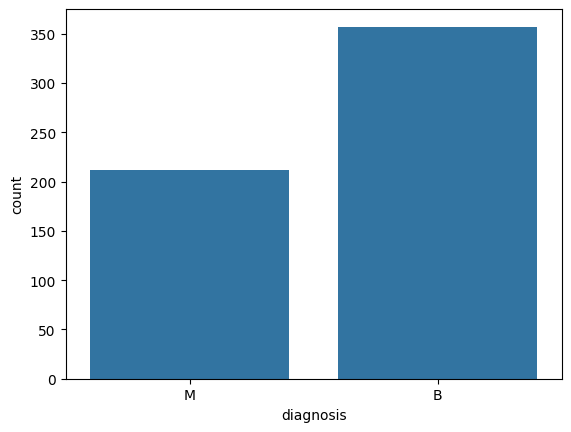

In [ ]:
sns.countplot(data=df, x='diagnosis')

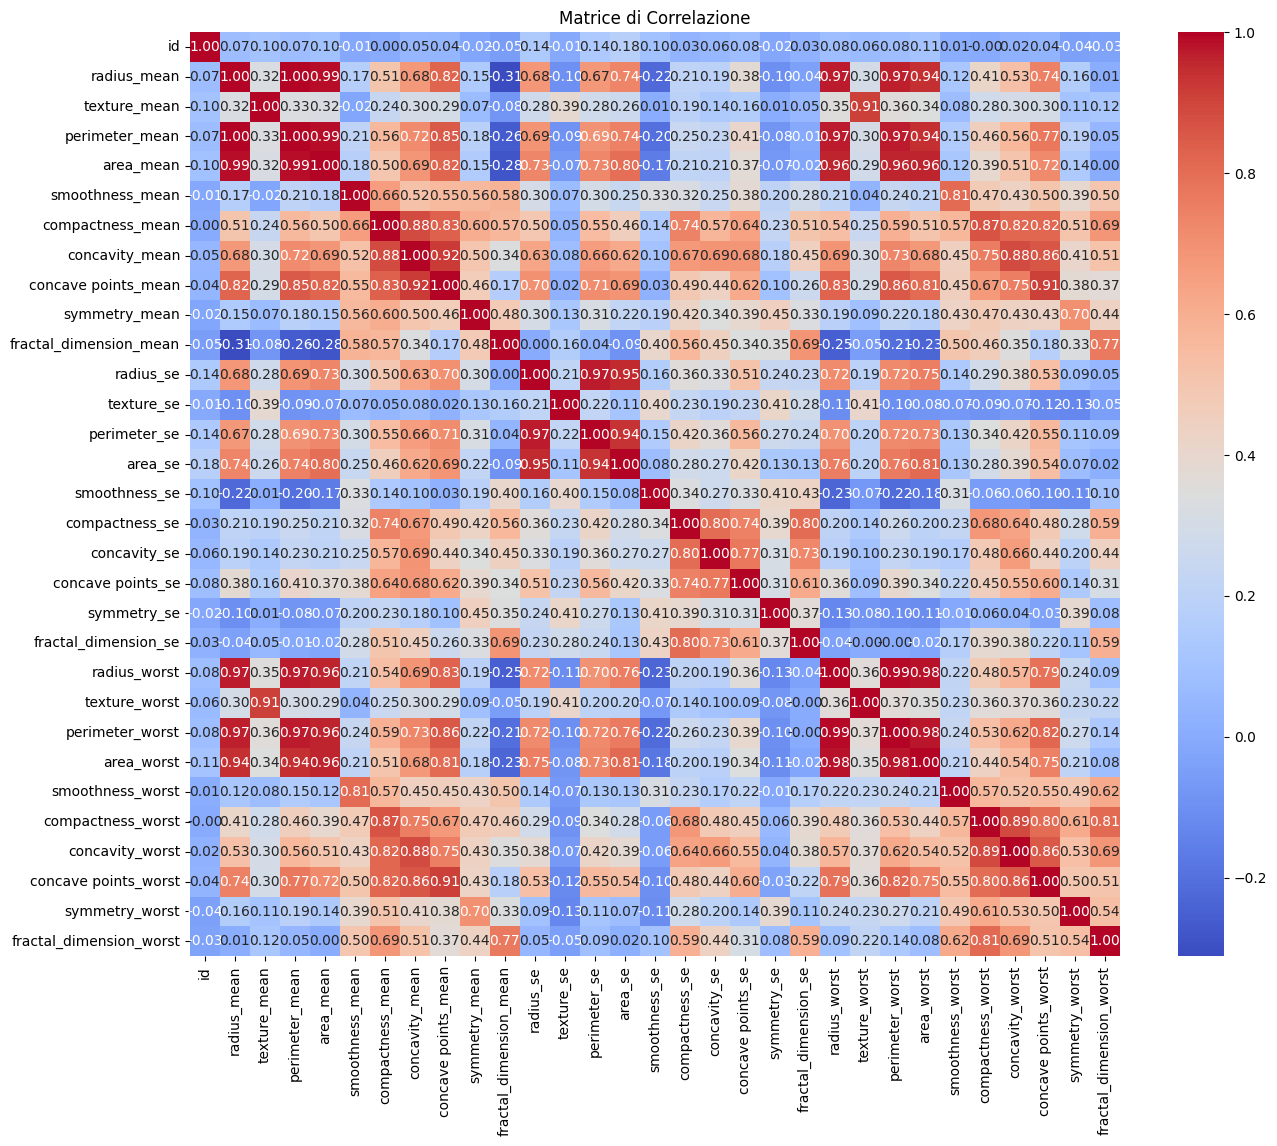

In [ ]:
# Calcola la matrice di correlazione (solo per colonne numeriche)
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Visualizza la matrice di correlazione (opzionale ma utile)
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di Correlazione')
plt.show()

In [ ]:
df[['radius_worst', 'perimeter_worst', 'area_worst']].corr()

,radius_worst,perimeter_worst,area_worst
radius_worst,1.000000,0.993708,0.984015
perimeter_worst,0.993708,1.000000,0.977578
area_worst,0.984015,0.977578,1.000000


In [ ]:
# Elenco delle colonne da eliminare
columns_to_drop = ['perimeter_mean', 'area_mean']

# drop() per eliminare le colonne
df = df.drop(columns=columns_to_drop)

# Puoi verificare le colonne rimanenti
print("\nColonne rimanenti nel dataset:")
print(df.columns)


Colonne rimanenti nel dataset:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se',
       'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se',
       'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


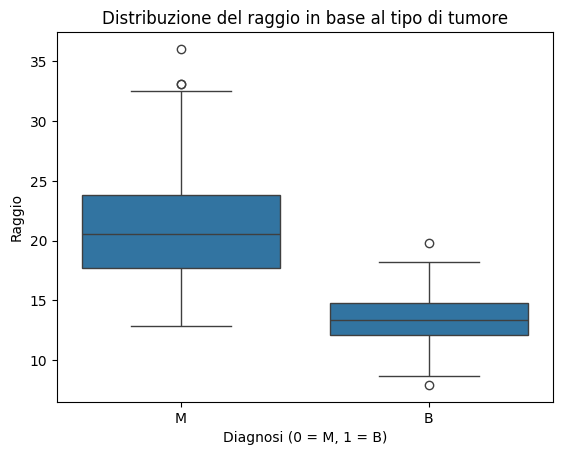

In [ ]:
# Boxplot dell'età per sopravvivenza
sns.boxplot(x='diagnosis', y='radius_worst', data=df)
plt.title('Distribuzione del raggio in base al tipo di tumore')
plt.xlabel('Diagnosi (0 = M, 1 = B)')
plt.ylabel('Raggio')
plt.show()

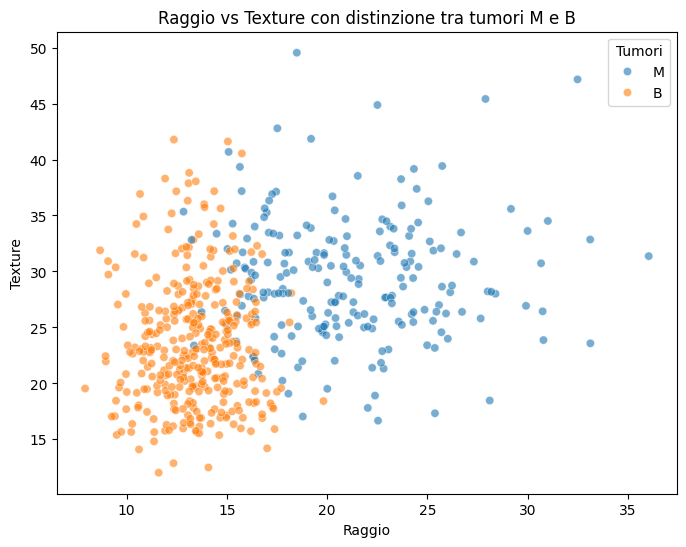


Informazioni generali sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    flo

In [ ]:
# Scatter plot: Raggio vs Texture in base alla tipo di tumore
plt.figure(figsize=(8, 6))
sns.scatterplot(x='radius_worst', y='texture_worst', hue='diagnosis', data=df, alpha=0.6)
plt.title('Raggio vs Texture con distinzione tra tumori M e B')
plt.xlabel('Raggio')
plt.ylabel('Texture')
plt.legend(title='Tumori')
plt.show()
print("\nInformazioni generali sul dataset:")
df.info()

In [ ]:
# Visualizza i valori unici nella colonna 'diagnosis' prima della conversione
print("Valori unici nella colonna 'diagnosis' prima della conversione:", df['diagnosis'].unique())

# Mappa i valori categorici a valori numerici
# Puoi scegliere l'assegnazione che preferisci (es. 'B': 0, 'M': 1)
# È comune assegnare 0 alla classe benigna e 1 alla classe maligna per problemi di classificazione binaria.
diagnosis_mapping = {'B': 0, 'M': 1}

# Applica la mappatura alla colonna 'diagnosis'
df['diagnosis'] = df['diagnosis'].map(diagnosis_mapping)

# Visualizza i valori unici nella colonna 'diagnosis' dopo la conversione
print("Valori unici nella colonna 'diagnosis' dopo la conversione:", df['diagnosis'].unique())

# Visualizza le prime righe del DataFrame per verificare la conversione
print("\nPrime righe del dataset dopo la conversione di 'diagnosis':")
print(df.head())

Valori unici nella colonna 'diagnosis' prima della conversione: ['M' 'B']
Valori unici nella colonna 'diagnosis' dopo la conversione: [1 0]

Prime righe del dataset dopo la conversione di 'diagnosis':
         id  diagnosis  radius_mean  texture_mean  smoothness_mean  \
0    842302          1        17.99         10.38          0.11840   
1    842517          1        20.57         17.77          0.08474   
2  84300903          1        19.69         21.25          0.10960   
3  84348301          1        11.42         20.38          0.14250   
4  84358402          1        20.29         14.34          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4  

In [ ]:
# Separazione tra variabili indipendenti e target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Suddivisione del dataset in training e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#rf_model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("\n[Random Forest] Report di classificazione:")
print(classification_report(y_test, rf_preds))
print("Accuratezza:", accuracy_score(y_test, rf_preds))


[Random Forest] Report di classificazione:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuratezza: 0.9649122807017544


In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test) #Qui il modello applica ciò che ha imparato sui dati mai visti prima (X_test).
print("\n[XGBoost] Report di classificazione:")
print(classification_report(y_test, xgb_preds))
print("Accuratezza:", accuracy_score(y_test, xgb_preds))


[XGBoost] Report di classificazione:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuratezza: 0.956140350877193


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:25:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
